/tmp/ipykernel_3281712/655757979.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x=enzyme_labels, y=enzyme_counts, palette=palette)
/tmp/ipykernel_3281712/655757979.py:32: UserWarning: Glyph 23376 (\N{CJK UNIFIED IDEOGRAPH-5B50}) missing from font(s) Arial.
  plt.tight_layout()
/tmp/ipykernel_3281712/655757979.py:32: UserWarning: Glyph 31867 (\N{CJK UNIFIED IDEOGRAPH-7C7B}) missing from font(s) Arial.
  plt.tight_layout()
/tmp/ipykernel_3281712/655757979.py:32: UserWarning: Glyph 37238 (\N{CJK UNIFIED IDEOGRAPH-9176}) missing from font(s) Arial.
  plt.tight_layout()
/tmp/ipykernel_3281712/655757979.py:32: UserWarning: Glyph 30340 (\N{CJK UNIFIED IDEOGRAPH-7684}) missing from font(s) Arial.
  plt.tight_layout()
/tmp/ipykernel_3281712/655757979.py:32: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s

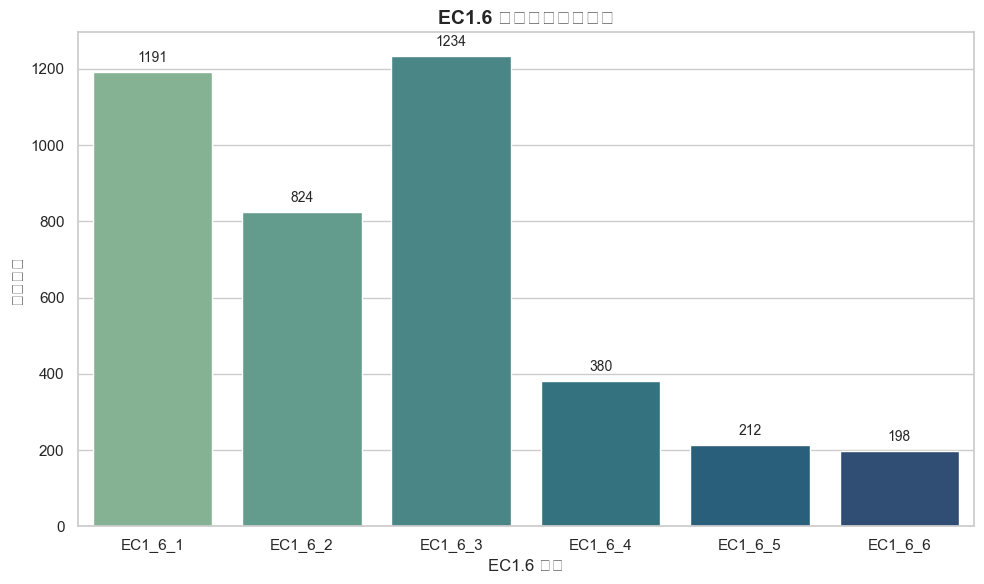

In [6]:
import zhplot
import matplotlib.pyplot as plt
import seaborn as sns

# 设置中文字体和Seaborn风格
# plt.rcParams['font.family'] = ['WenQuanYi Micro Hei']
# plt.rcParams['axes.unicode_minus'] = False

sns.set(style="whitegrid")

# EC 1.6各类酶的数量
enzyme_labels = ['EC1_6_1', 'EC1_6_2', 'EC1_6_3', 'EC1_6_4', 'EC1_6_5', 'EC1_6_6']
enzyme_counts = [1191, 824, 1234, 380, 212, 198]

# 创建绘图
plt.figure(figsize=(10, 6))
palette = sns.color_palette("crest", len(enzyme_counts))
bars = sns.barplot(x=enzyme_labels, y=enzyme_counts, palette=palette)

# 添加数值标签
for bar in bars.patches:
    height = bar.get_height()
    bars.annotate(f'{int(height)}',
                  xy=(bar.get_x() + bar.get_width() / 2, height),
                  xytext=(0, 5),  # y偏移量
                  textcoords="offset points",
                  ha='center', va='bottom', fontsize=10)

plt.title('EC1.6 各类酶的分布统计', fontsize=14, weight='bold')
plt.xlabel('EC1.6 子类', fontsize=12)
plt.ylabel('酶的数量', fontsize=12)
plt.tight_layout()

plt.show()


In [6]:
from matplotlib import pyplot as plt
import matplotlib
a=sorted([f.name for f in matplotlib.font_manager.fontManager.ttflist])

for i in a:
    print(i)

AR PL KaitiM Big5
AR PL KaitiM GB
AR PL Mingti2L Big5
AR PL SungtiL GB
AR PL UKai CN
AR PL UMing CN
Abyssinica SIL
Accanthis ADF Std
Accanthis ADF Std
Accanthis ADF Std
Accanthis ADF Std
Accanthis ADF Std No2
Accanthis ADF Std No2
Accanthis ADF Std No2
Accanthis ADF Std No2
Accanthis ADF Std No3
Accanthis ADF Std No3
Accanthis ADF Std No3
Accanthis ADF Std No3
Amiri
Amiri
Amiri
Amiri
Amiri Quran
Amiri Quran Colored
Andale Mono
Andale Mono
Ani
AnjaliOldLipi
Arial
Arial
Arial
Arial
Arial
Arial
Arial
Arial
Arial Black
Arial Black
Arimo
Arimo
Arimo
Arimo
Asana Math
Baekmuk Batang
Baekmuk Dotum
Baekmuk Gulim
Baekmuk Headline
Berenis ADF Pro
Berenis ADF Pro
Berenis ADF Pro
Berenis ADF Pro
Berenis ADF Pro Math
C059
C059
C059
C059
Cabin
Cabin
Cabin
Cabin
Cabin
Cabin
Cabin
Cabin
Caladea
Caladea
Caladea
Caladea
Cantarell
Cantarell
Cantarell
Cantarell
Cantarell
Carlito
Carlito
Carlito
Carlito
Chandas
Charis SIL
Charis SIL
Charis SIL
Charis SIL
Chilanka
Comfortaa
Comfortaa
Comfortaa
Comic Sans MS


In [7]:
import os
import torch
import logging
from transformers import AutoTokenizer, EsmForProteinFolding
from transformers.models.esm.openfold_utils.protein import Protein as OFProtein, to_pdb
from transformers.models.esm.openfold_utils.feats import atom14_to_atom37
import requests
import hashlib

def convert_outputs_to_pdb(outputs):
    final_atom_positions = atom14_to_atom37(outputs["positions"][-1], outputs)
    outputs = {k: v.to("cpu").numpy() for k, v in outputs.items()}
    final_atom_positions = final_atom_positions.cpu().numpy()
    final_atom_mask = outputs["atom37_atom_exists"]

    pdbs = []
    for i in range(outputs["aatype"].shape[0]):
        aa = outputs["aatype"][i]
        pred_pos = final_atom_positions[i]
        mask = final_atom_mask[i]
        resid = outputs["residue_index"][i] + 1
        pred = OFProtein(
            aatype=aa,
            atom_positions=pred_pos,
            atom_mask=mask,
            residue_index=resid,
            b_factors=outputs["plddt"][i],
            chain_index=outputs["chain_index"][i] if "chain_index" in outputs else None,
        )
        pdbs.append(to_pdb(pred))
    return pdbs

class StructureFetcher:
    def __init__(self, save_dir="output/pdb_files"):
        self.save_dir = save_dir
        os.makedirs(save_dir, exist_ok=True)
        self.stats = {
            "pdb_download": 0,
            "esm_predicted": 0,
            "failed": 0
        }

    def _get_cache_path(self, uniprot_id, sequence):
        seq_hash = hashlib.sha1(sequence.encode()).hexdigest()[:8]
        return os.path.join(self.save_dir, f"{uniprot_id}_{seq_hash}.pdb")

    def _save_pdb_file(self, content, uniprot_id, seq_hash):
        path = os.path.join(self.save_dir, f"{uniprot_id}.pdb")
        with open(path, 'w') as f:
            f.write(content)

    def _try_download_pdb(self, uniprot_id, save_path):
        url = f"https://www.rcsb.org/fasta/entry/{uniprot_id}/display"
        response = requests.get(url)
        if response.status_code == 200:
            pdb_url = f"https://files.rcsb.org/download/{uniprot_id}.pdb"
            r = requests.get(pdb_url)
            if r.status_code == 200:
                with open(save_path, 'w') as f:
                    f.write(r.text)
                return True
        return False

    def fetch(self, uniprot_id, sequence):
        seq_hash = hashlib.sha1(sequence.encode()).hexdigest()[:8]
        pdb_cache_path = self._get_cache_path(uniprot_id, sequence)

        # 1. 尝试下载已有结构
        if uniprot_id and self._try_download_pdb(uniprot_id, pdb_cache_path):
            with open(pdb_cache_path, 'r') as f:
                pdb_content = f.read()
            self.stats["pdb_download"] += 1
            return pdb_content

        # 2. 若失败则使用ESMFold预测
        try:
            tokenizer = AutoTokenizer.from_pretrained("facebook/esmfold_v1")
            model = EsmForProteinFolding.from_pretrained("facebook/esmfold_v1", low_cpu_mem_usage=True).cuda()
            model.eval()

            tokenized_input = tokenizer([sequence], return_tensors="pt", add_special_tokens=False)['input_ids'].cuda()
            with torch.no_grad():
                output = model(tokenized_input)

            pdb_content = convert_outputs_to_pdb(output)[0]
            self._save_pdb_file(pdb_content, uniprot_id, seq_hash)
            self.stats["esm_predicted"] += 1
            return pdb_content

        except Exception as e:
            logging.error(f"ESMFold prediction failed for {uniprot_id}: {e}")
            dummy = self._create_dummy_pdb(sequence)
            self._save_pdb_file(dummy, uniprot_id, seq_hash)
            self.stats["failed"] += 1
            return dummy

    def _create_dummy_pdb(self, sequence):
        lines = ["HEADER    DUMMY STRUCTURE\n"]
        for i, aa in enumerate(sequence[:10]):
            lines.append(f"ATOM  {i+1:5d}  CA  {aa} A{i+1:4d}    {0.0+i:8.3f}{0.0:8.3f}{0.0:8.3f}  1.00  0.00           C\n")
        lines.append("END\n")
        return ''.join(lines)



In [8]:
fetcher = StructureFetcher(save_dir="output/pdb_structures")
sequence = "MVHVRKNHLTMTAEEKRRFVHAVLEIKRRGIYDRFVKLHIQINSTDYLDKETGKRLGHVNPGFLPWHRQYLLKFEQALQKVDPRVTLPYWDWTTDHGENSPLWSDTFMGGNGRPGD"
uniprot = "TESTCASE001"

pdb_str = fetcher.fetch(uniprot_id=uniprot, sequence=sequence)
print(pdb_str[:300])

Some weights of EsmForProteinFolding were not initialized from the model checkpoint at facebook/esmfold_v1 and are newly initialized: ['esm.contact_head.regression.bias', 'esm.contact_head.regression.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


PARENT N/A
ATOM      1  N   MET A   1      13.212  -2.567 -14.731  1.00  0.58           N  
ATOM      2  CA  MET A   1      11.839  -2.796 -15.172  1.00  0.59           C  
ATOM      3  C   MET A   1      10.867  -1.896 -14.417  1.00  0.60           C  
ATOM      4  CB  MET A   1      11.450  -4.263
